In [1]:
import os
from tqdm import tqdm
from PIL import Image, ImageOps
import numpy as np

# Base directories for healthy and sick images
healthy_base_directory = '/kaggle/input/dmr-data/DMR - Database For Mastology Research - Visual Lab, UFF, Niterói, Brazil/Healthy'
sick_base_directory = '/kaggle/input/dmr-data/DMR - Database For Mastology Research - Visual Lab, UFF, Niterói, Brazil/Sick'

# Create lists to store the image data, labels, and patient IDs
image_data = []
labels = []
patient_ids = []

# List of patient IDs to exclude
exclude_patient_ids = {'197', '109', '185', '276', '242'}

# Helper function to load and resize images from a folder
def load_images_from_folder(folder, target_size=(640, 640)):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith('.jpg'):  # Only load .jpg files
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert('RGB')  # Convert to RGB format
            img = img.resize((640, 480))  # Resize to 640x480 first
            
            # Add padding to make it 640x640 (center the image)
            padding = (0, (640 - 480) // 2, 0, (640 - 480) // 2)  # (left, top, right, bottom)
            img = ImageOps.expand(img, padding)  # Pad the image to 640x640
            
            img_array = np.array(img)  # Convert image to a numpy array
            images.append(img_array)
    return images

# Function to load static images for a patient
def load_static_images(base_directory, patient_folder):
    patient_images = []
    visit_01_static_path = os.path.join(base_directory, patient_folder, 'visit_01', 'images', 'thermography', 'static')
    
    if os.path.exists(visit_01_static_path):
        patient_images.extend(load_images_from_folder(visit_01_static_path))
        
    return patient_images

# Function to load dynamic images for a patient with unique prefixes
def load_dynamic_images(base_directory, patient_folder, existing_prefixes):
    patient_images = []
    visit_01_dynamic_path = os.path.join(base_directory, patient_folder, 'visit_01', 'images', 'thermography', 'dynamic')
    
    if os.path.exists(visit_01_dynamic_path):
        for filename in os.listdir(visit_01_dynamic_path):
            if filename.endswith('.jpg'):  # Only load .jpg files
                try:
                    prefix = filename.split('.')[2]  # Extract the prefix TXXX.1.Y
                    if prefix not in existing_prefixes:
                        img_path = os.path.join(visit_01_dynamic_path, filename)
                        img = Image.open(img_path).convert('RGB')
                        img = img.resize((640, 480))  # Resize to 640x480 first

                        # Add padding to make it 640x640 (center the image)
                        padding = (0, (640 - 480) // 2, 0, (640 - 480) // 2)  # (left, top, right, bottom)
                        img = ImageOps.expand(img, padding)  # Pad the image to 640x640

                        img_array = np.array(img)  # Convert image to a numpy array
                        patient_images.append(img_array)
                        existing_prefixes.add(prefix)  # Add the prefix to the set
                except Exception as e:
                    print(f"Error loading image {filename}: {e}")  # Log the error message
    return patient_images

# Function to load specific dynamic images for patient p247
def load_patient_247_images(base_directory, patient_folder):
    patient_images = []
    visit_01_dynamic_path = os.path.join(base_directory, patient_folder, 'visit_01', 'images', 'thermography', 'dynamic')
    
    if os.path.exists(visit_01_dynamic_path):
        # Define the unique prefixes we want to load
        desired_prefixes = ['TFRON', 'TLL90', 'TLL45', 'TLR90', 'TLR45']
        loaded_prefixes = set()  # To track which prefixes have been loaded

        for filename in os.listdir(visit_01_dynamic_path):
            if filename.endswith('.jpg'):  # Only load .jpg files
                try:
                    prefix = filename.split('_')[0]  # Extract the prefix
                    if prefix in desired_prefixes and prefix not in loaded_prefixes:
                        img_path = os.path.join(visit_01_dynamic_path, filename)
                        img = Image.open(img_path).convert('RGB')
                        img = img.resize((640, 480))  # Resize to 640x480 first

                        # Add padding to make it 640x640 (center the image)
                        padding = (0, (640 - 480) // 2, 0, (640 - 480) // 2)  # (left, top, right, bottom)
                        img = ImageOps.expand(img, padding)  # Pad the image to 640x640

                        img_array = np.array(img)  # Convert image to a numpy array
                        patient_images.append(img_array)
                        loaded_prefixes.add(prefix)  # Mark this prefix as loaded
                        patient_ids.append(patient_folder)
                except Exception as e:
                    print(f"Error loading image {filename}: {e}")  # Log the error message
    return patient_images

# Function to load images for a patient
def load_patient_images(base_directory, patient_folder, label, existing_prefixes):
    patient_id = patient_folder  # Use the raw patient_folder name as ID (no 'p' prefix)
    
    # Exclude specific patient IDs
    if patient_id in exclude_patient_ids:
        return []

    # Special handling for patient p247
    if patient_id == 'p247':
        return load_patient_247_images(base_directory, patient_folder)

    patient_images = load_static_images(base_directory, patient_folder)
    
    # If no static images, load dynamic images with unique prefixes
    if not patient_images:
        patient_images = load_dynamic_images(base_directory, patient_folder, existing_prefixes)
    if patient_images:
        patient_ids.extend([patient_id] * len(patient_images))
    print(f"Patient ID: {patient_id}, Label: {label}, Number of images loaded: {len(patient_images)}")
    return patient_images

# Set to store existing dynamic image prefixes
existing_dynamic_prefixes = set()

# Traverse through each patient's folder for healthy patients
for patient_folder in tqdm(os.listdir(healthy_base_directory), desc="Loading Healthy Patients"):
    images = load_patient_images(healthy_base_directory, patient_folder, label=1, existing_prefixes=existing_dynamic_prefixes)
    image_data.extend(images)
    labels.extend([1] * len(images))  # Label all healthy images with 1

# Traverse through each patient's folder for sick patients
for patient_folder in tqdm(os.listdir(sick_base_directory), desc="Loading Sick Patients"):
    images = load_patient_images(sick_base_directory, patient_folder, label=0, existing_prefixes=existing_dynamic_prefixes)
    image_data.extend(images)
    labels.extend([0] * len(images))  # Label all sick images with 0

# Convert the data into numpy arrays for further use
image_data = np.array(image_data)
labels = np.array(labels)
patient_ids = np.array(patient_ids)  # Convert patient IDs to a numpy array

print(f"Total images loaded: {len(image_data)}")


Loading Healthy Patients:   3%|▎         | 5/192 [00:00<00:03, 49.28it/s]

Patient ID: p135, Label: 1, Number of images loaded: 0
Patient ID: p62, Label: 1, Number of images loaded: 0
Patient ID: p201, Label: 1, Number of images loaded: 5
Patient ID: p300, Label: 1, Number of images loaded: 0
Patient ID: p18, Label: 1, Number of images loaded: 0
Patient ID: p07, Label: 1, Number of images loaded: 3
Patient ID: p50, Label: 1, Number of images loaded: 0
Patient ID: p34, Label: 1, Number of images loaded: 4
Patient ID: p215, Label: 1, Number of images loaded: 0


Loading Healthy Patients:   9%|▉         | 18/192 [00:00<00:02, 58.77it/s]

Patient ID: p17, Label: 1, Number of images loaded: 5
Patient ID: p51, Label: 1, Number of images loaded: 0
Patient ID: p49, Label: 1, Number of images loaded: 0
Patient ID: p189, Label: 1, Number of images loaded: 0
Patient ID: p116, Label: 1, Number of images loaded: 5
Patient ID: p146, Label: 1, Number of images loaded: 0
Patient ID: p36, Label: 1, Number of images loaded: 0
Patient ID: p190, Label: 1, Number of images loaded: 0
Patient ID: p92, Label: 1, Number of images loaded: 5
Patient ID: p162, Label: 1, Number of images loaded: 0
Patient ID: p216, Label: 1, Number of images loaded: 5
Patient ID: p177, Label: 1, Number of images loaded: 0
Patient ID: p200, Label: 1, Number of images loaded: 5


Loading Healthy Patients:  19%|█▉        | 36/192 [00:00<00:02, 71.70it/s]

...

Patient ID: p258, Label: 0, Number of images loaded: 4


Loading Sick Patients:  87%|████████▋ | 40/46 [00:01<00:00, 29.44it/s]

Patient ID: p283, Label: 0, Number of images loaded: 5
Patient ID: p181, Label: 0, Number of images loaded: 0
Patient ID: p267, Label: 0, Number of images loaded: 5
Patient ID: p273, Label: 0, Number of images loaded: 5
Patient ID: p209, Label: 0, Number of images loaded: 0
Patient ID: p270, Label: 0, Number of images loaded: 5
Patient ID: p204, Label: 0, Number of images loaded: 0
Patient ID: p278, Label: 0, Number of images loaded: 0
Patient ID: p251, Label: 0, Number of images loaded: 0


Loading Sick Patients: 100%|██████████| 46/46 [00:01<00:00, 32.80it/s]


Patient ID: p256, Label: 0, Number of images loaded: 5
Total images loaded: 389


In [2]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test, patient_ids_train, patient_ids_test = train_test_split(
    image_data, labels, patient_ids, test_size=0.15, random_state=42, stratify=labels
)

# Check shapes to ensure everything is aligned
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}, patient_ids_train shape: {patient_ids_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}, patient_ids_test shape: {patient_ids_test.shape}")

2025-09-03 09:56:37.633993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756893397.961099      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756893398.055088      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


X_train shape: (330, 640, 640, 3), y_train shape: (330,), patient_ids_train shape: (330,)
X_test shape: (59, 640, 640, 3), y_test shape: (59,), patient_ids_test shape: (59,)


In [3]:
from sklearn.utils.class_weight import compute_class_weight
compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)

array([1.43478261, 0.76744186])

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, 
                             roc_curve, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

# Split training set into train and validation sets
X_train, X_val, y_train, y_val, patient_ids_train, patient_ids_val = train_test_split(
    X_train, y_train, patient_ids_train, test_size=0.15, random_state=42, stratify=y_train)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Update the evaluate_model function to include additional graphs and metrics
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, patient_ids_test):
    # Compute class weights to handle imbalanced data
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights_dict = dict(enumerate(class_weights))
    
    # Train the model with early stopping and class weights
    history = model.fit(X_train, y_train, epochs=200, batch_size=32, 
                        validation_data=(X_val, y_val),
                        class_weight=class_weights_dict,
                        callbacks=[early_stopping])
    
    history_df = pd.DataFrame(history.history)
    history_df['epoch'] = history.epoch
    history_df.to_csv("vgg16_training_history.csv", index=False)
    
    # Evaluate the model on the test and train sets
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    train_loss, train_accuracy = model.evaluate(X_train, y_train)
    
    # Calculate AUROC for test and train sets
    y_pred_proba_test = model.predict(X_test).ravel()
    y_pred_proba_train = model.predict(X_train).ravel()
    
    test_auroc = roc_auc_score(y_test, y_pred_proba_test)
    train_auroc = roc_auc_score(y_train, y_pred_proba_train)
    
    print(f"Train Accuracy: {train_accuracy:.4f}, AUROC: {train_auroc:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}, AUROC: {test_auroc:.4f}")

    # Generate binary predictions from probabilities
    y_pred = (y_pred_proba_test >= 0.5).astype(int)
    
    # Calculate F1 score, Precision, Sensitivity (Recall)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)  # Sensitivity is the same as Recall
    
    # Calculate Specificity (True Negative Rate)
    cm_test = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm_test.ravel()
    specificity = tn / (tn + fp)
    
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

    prediction_df = pd.DataFrame({
        'patient_id': patient_ids_test,
        'y_test': y_test,
        'y_pred_proba': y_pred_proba_test,
        'y_pred': y_pred
    })
    prediction_df.to_csv("vgg16_predictions.csv", index=False)
    
    # Confusion matrix for test set
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", 
                xticklabels=['Sick', 'Healthy'], yticklabels=['Sick', 'Healthy'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix (Test Accuracy: {test_accuracy:.4f})')
    plt.show()
    
    # Plot training & validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Plot training & validation accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, marker='o', color='orange', label='CNN')
    plt.plot([0, 1], [0, 1], linestyle='--', color='blue', label='No Skill')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_test)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='o', color='orange', label='CNN')
    plt.plot([0, 1], [0.5, 0.5], linestyle='--', color='blue', label='No Skill')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()
    
    # Lift Chart (Cumulative Gain Chart)
    # Sort predictions by probability
    sorted_indices = np.argsort(y_pred_proba_test)[::-1]
    sorted_y_test = y_test[sorted_indices]
    cumulative_gain = np.cumsum(sorted_y_test) / np.sum(sorted_y_test)
    
    # Random model for comparison (cumulative gain is linear)
    random_gain = np.arange(1, len(y_test) + 1) / len(y_test)
    
    plt.figure(figsize=(8, 6))
    plt.plot(cumulative_gain, label='Model', color='orange')
    plt.plot(random_gain, label='Random', linestyle='--', color='blue')
    plt.xlabel('Number of Samples')
    plt.ylabel('Cumulative Gain')
    plt.title('Lift Chart (Cumulative Gain)')
    plt.legend()
    plt.show()
    
    return 1


I0000 00:00:1756893416.500843      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756893416.501558      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Evaluating VGG16...
Epoch 1/200


I0000 00:00:1756893422.249773      95 service.cc:148] XLA service 0x7e0280011300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756893422.251466      95 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756893422.251494      95 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756893422.762421      95 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-09-03 09:57:15.051653: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=0,k4=1,k5=1,k6=0,k7=0,k19=0} for conv (f32[32,64,640,640]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,640,640]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale

8/9 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.5161 - loss: 1.1008

2025-09-03 09:59:11.644808: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=3,k3=0} for conv (f32[24,64,640,640]{3,2,1,0}, u8[0]{0}) custom-call(f32[24,64,640,640]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-09-03 09:59:12.055970: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.411261165s
Trying algorithm eng11{k2=3,k3=0} for conv (f32[24,64,640,640]{3,2,1,0}, u8[0]{0}) custom-call(f32[24,64,640,640]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5155 - loss: 1.0986

2025-09-03 10:00:37.096645: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=3,k3=0} for conv (f32[18,64,640,640]{3,2,1,0}, u8[0]{0}) custom-call(f32[18,64,640,640]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-09-03 10:00:37.186138: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.089614186s
Trying algorithm eng11{k2=3,k3=0} for conv (f32[18,64,640,640]{3,2,1,0}, u8[0]{0}) custom-call(f32[18,64,640,640]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF

9/9 ━━━━━━━━━━━━━━━━━━━━ 275s 21s/step - accuracy: 0.5151 - loss: 1.0969 - val_accuracy: 0.4400 - val_loss: 0.9222
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5113 - loss: 0.9508 - val_accuracy: 0.7000 - val_loss: 0.7571
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6342 - loss: 0.8276 - val_accuracy: 0.6400 - val_loss: 0.8099
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6391 - loss: 0.7393 - val_accuracy: 0.6400 - val_loss: 0.7520
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5822 - loss: 0.7873 - val_accuracy: 0.6800 - val_loss: 0.7431
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7524 - loss: 0.6996 - val_accuracy: 0.6600 - val_loss: 0.7897
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7058 - loss: 0.6906 - val_accuracy: 0.6800 - val_loss: 0.6974
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7431 - loss: 0.6510 - val_accuracy: 0.6400 - val_loss: 0.7864
Epoch 9/20

2025-09-03 10:14:13.294594: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=2,k4=2,k5=0,k6=0,k7=0,k19=0} for conv (f32[27,64,640,640]{3,2,1,0}, u8[0]{0}) custom-call(f32[27,64,640,640]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-09-03 10:14:13.305951: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.011470658s
Trying algorithm eng20{k2=2,k4=2,k5=0,k6=0,k7=0,k19=0} for conv (f32[27,64,640,640]{3,2,1,0}, u8[0]{0}) custom-call(f32[27,64,640,640]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custo

2/2 ━━━━━━━━━━━━━━━━━━━━ 96s 94s/step - accuracy: 0.7585 - loss: 0.5339
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8749 - loss: 0.4149
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Train Accuracy: 0.8929, AUROC: 0.9702
Test Accuracy: 0.7627, AUROC: 0.8759
F1 Score: 0.8250
Precision: 0.7857
Sensitivity (Recall): 0.8684
Specificity: 0.5714


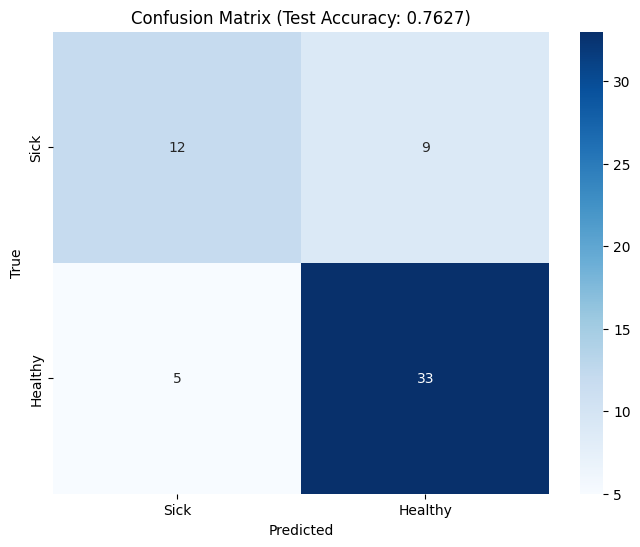

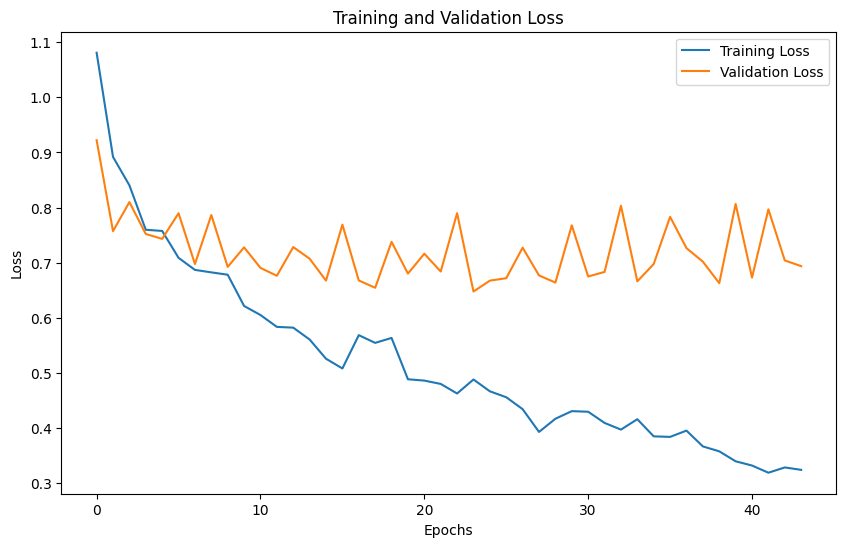

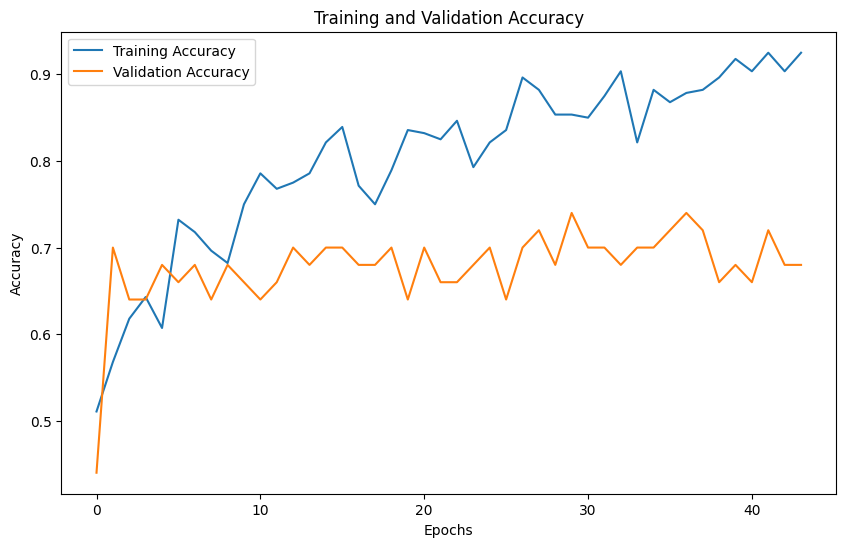

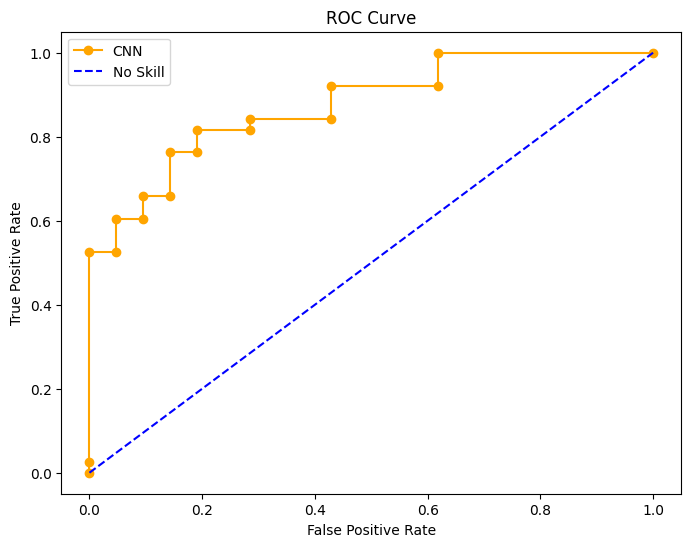

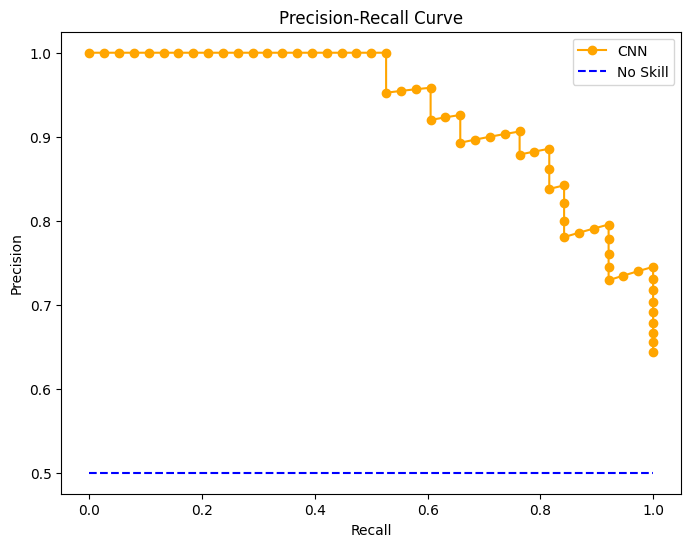

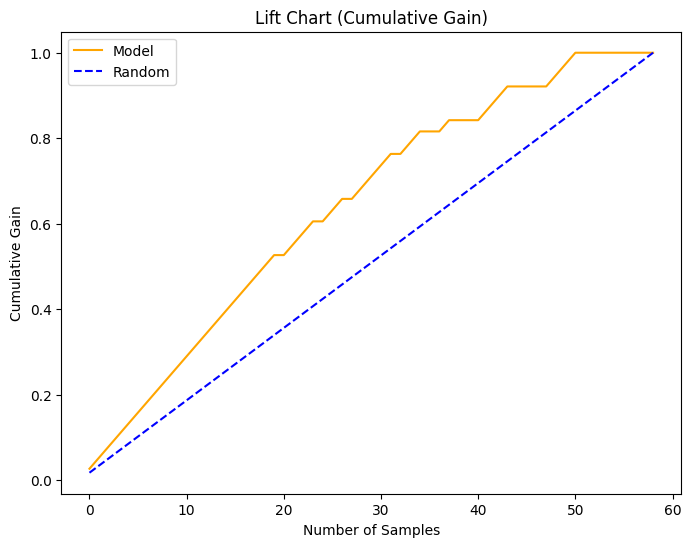

In [5]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import VGG16
from sklearn.metrics import roc_curve, precision_recall_curve
# VGG16 model
def create_vgg16_model(input_shape=(640, 640, 3)):
    # Load VGG16 with pretrained weights, excluding the fully connected top layers
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base layers

    # Add custom layers for binary classification
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001))
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create the VGG16 model
vgg16_model = create_vgg16_model(input_shape=(640, 640, 3))

# Assuming X_train, y_train, X_val, y_val, X_test, and y_test are already defined
# Evaluate the VGG16 model using your evaluate_model function
print("Evaluating VGG16...")
mismatch_df_vgg16 = evaluate_model(vgg16_model, X_train, y_train, X_val, y_val, X_test, y_test, patient_ids_test)


In [6]:
# import shap
# import numpy as np
# import matplotlib.pyplot as plt
# from tensorflow.keras.applications.vgg16 import preprocess_input

# # Define the custom prediction function
# def predict_function(x):
#     # Ensure images are preprocessed correctly for VGG16
#     return vgg16_model.predict(preprocess_input(x))

# # Create an image masker
# masker = shap.maskers.Image("inpaint_telea", (640, 640, 3))

# # Create SHAP explainer with your VGG16 model and masker
# explainer = shap.Explainer(predict_function, masker, output_names=["Healthy", "Sick"])

# # Select five images to explain (replace `X_test` with the subset of your choice)
# sample_images = X_test[:10]  # Assuming X_test contains images to evaluate

# # Generate SHAP values
# shap_values = explainer(sample_images, max_evals=100, batch_size=10, outputs=shap.Explanation.argsort.flip[:2])

In [7]:
# for i in range(10):
#     shap.image_plot(shap_values[i])